In [67]:
from traceback import extract_stack

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from jupyter_client.jsonutil import squash_dates
from prompt_toolkit.data_structures import Size
from scipy.constants import year

DB = pd.read_csv("DS3.csv")
print(DB)

     Unnamed: 0    emp_id  age        Dept location education  \
0             0    HR8270   28          HR   Suburb        PG   
1             1  TECH1860   50  Technology   Suburb        PG   
2             2  TECH6390   43  Technology   Suburb        UG   
3             3   SAL6191   44       Sales     City        PG   
4             4    HR6734   33          HR     City        UG   
..          ...       ...  ...         ...      ...       ...   
495         495    HR5330   49          HR   Suburb        PG   
496         496  TECH9010   24  Technology   Suburb        UG   
497         497   MKT7801   34   Marketing     City        PG   
498         498  TECH5846   26  Technology     City        UG   
499         499  TECH7731   26  Technology     City        UG   

       recruitment_type  job_level  rating  onsite  awards  certifications  \
0              Referral          5       2       0       1               0   
1               Walk-in          3       5       1       2     

In [68]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

DB_Alter1 = DB.copy()
DB_Alter1 = DB_Alter1.drop(columns=["emp_id","recruitment_type","Unnamed: 0"])
DB_Alter1 = DB_Alter1.dropna()

In [69]:
dept_encoded = pd.get_dummies(DB_Alter1["Dept"], prefix="Dept", dtype=int)

# Unir las nuevas columnas al DataFrame y eliminar la original 'Dept'
DB_Alter1 = pd.concat([DB_Alter1, dept_encoded], axis=1)
DB_Alter1 = DB_Alter1.drop(columns=["Dept"])
normalizar = ["age","job_level","rating","awards","salary"]
# Normalizar
scaler_min = MinMaxScaler()
DB_Alter1[normalizar] = scaler_min.fit_transform(DB_Alter1[normalizar])
print(DB_Alter1)
print(DB_Alter1.head())

          age location education  job_level  rating  onsite    awards  \
0    0.161290   Suburb        PG       1.00    0.25       0  0.111111   
1    0.870968   Suburb        PG       0.50    1.00       1  0.222222   
2    0.645161   Suburb        UG       0.75    0.00       0  0.222222   
3    0.677419     City        PG       0.25    0.50       1  0.000000   
4    0.322581     City        UG       0.25    0.00       0  0.555556   
..        ...      ...       ...        ...     ...     ...       ...   
495  0.838710   Suburb        PG       0.25    1.00       0  0.666667   
496  0.032258   Suburb        UG       0.25    0.75       0  0.222222   
497  0.354839     City        PG       0.00    0.50       0  0.222222   
498  0.096774     City        UG       0.25    0.00       1  0.111111   
499  0.096774     City        UG       0.50    0.75       0  0.333333   

     certifications    salary  satisfied  Dept_HR  Dept_Marketing  \
0                 0  1.000000          1        1     

In [70]:
DB_Alter1[normalizar] = DB_Alter1[normalizar].round(2)

In [71]:
dic_DB_location = {"Suburb": 0, "City": 1}
dic_DB_education = {"PG": 0, "UG": 1}
DB_Alter1["location"] = DB_Alter1["location"].map(dic_DB_location).astype(int)
DB_Alter1["education"] = (
    DB_Alter1["education"].map(dic_DB_education).astype(int)
)

In [72]:
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout
import tensorflow as tf


y = DB_Alter1["satisfied"]
x = DB_Alter1.drop("satisfied", axis=1)

#y = DB_Alter["class"]
#x = DB_Alter.drop("class", axis=1)
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=21,stratify=y)

print("Características de entrada:", x_train.shape[1])
print("Class:", y.nunique())

model = Sequential()
model.add(Dense(16,input_dim=x_train.shape[1],activation="relu"))
model.add(Dense(8,activation="relu"))

model.add(Dense(1,activation="sigmoid"))
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])
history = model.fit(x_train,y_train,epochs=100,batch_size=16,validation_split=0.2,verbose=1)

result = model.evaluate(x_test,y_test,verbose=1)
print("Loss:", result[0])
print("Accuracy:", result[1])

Características de entrada: 14
Class: 2
Epoch 1/100


C:\Users\hecto\PycharmProjects\Redes\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5357 - loss: 0.7021 - val_accuracy: 0.5143 - val_loss: 0.7036
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5321 - loss: 0.6964 - val_accuracy: 0.5286 - val_loss: 0.7010
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5393 - loss: 0.6944 - val_accuracy: 0.5000 - val_loss: 0.6998
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5429 - loss: 0.6920 - val_accuracy: 0.5286 - val_loss: 0.7004
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5321 - loss: 0.6907 - val_accuracy: 0.5286 - val_loss: 0.6997
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5393 - loss: 0.6886 - val_accuracy: 0.5143 - val_loss: 0.6984
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5571 - loss: 0.6871 - val_accuracy: 0.5143 - val_loss: 0.6975
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5571 - loss: 0.6864 - val_accuracy: 0.5286 - val_loss

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


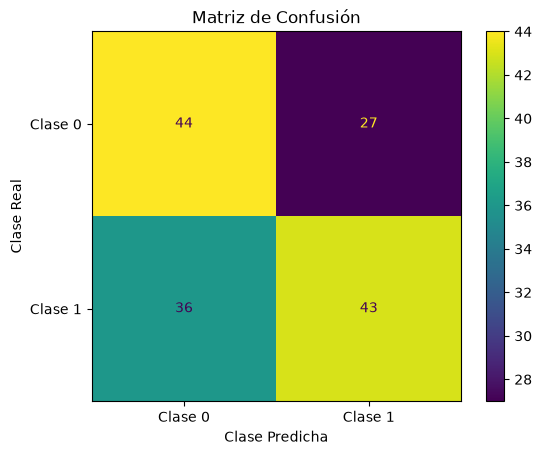

In [73]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Predicciones del modelo (Probabilidades entre 0 y 1)
y_pred_probs = model.predict(x_test)

# FIX: Convertir probabilidades a la clase predicha usando un umbral de 0.5
y_pred = (y_pred_probs > 0.5).astype(int)

# Crear matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Mostrar matriz
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Clase 0", "Clase 1"]
)

disp.plot(cmap="viridis")

plt.title("Matriz de Confusión")
plt.xlabel("Clase Predicha")
plt.ylabel("Clase Real")
plt.show()